# MLC セルノイズ可視化 (6-bit 量子化)

6-bit 量子化された値 $q \in [0, 63]$ を重みスケール $w \in [-1, 1]$ にマッピングし、以下の3パターンでセル分解した場合のノイズ挙動を可視化する。

| 構成 | cell_bits | セル数 | cell_max (セル最大値) |
|------|-----------|--------|----------------------|
| 6bit/cell | 6 | 1 | 63 |
| 3bit/cell | 3 | 2 | 7 |
| 2bit/cell | 2 | 3 | 3 |

**ノイズモデル**: 各セル $i$ に独立ガウスノイズ $\mathcal{N}(0,\; \sigma \times \text{cell\_max})$ を加算する。

$\sigma$ は **[-1, 1] 重み空間に対する正規化標準偏差 (n.s.)** として指定する。各セルの最大レベル数に比例したノイズが注入され、MSB セルほど出力への影響が大きい。

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

In [4]:
def inject_noise_mlc(q_int, sigma, bits=6, cell_bits=6, n_trials=10000):
    """
    MLC cell-level ノイズ注入

    Parameters
    ----------
    q_int    : (N,) int tensor, 量子化値 [0, 2^bits - 1]
    sigma    : float, 正規化シグマ (各セルへのノイズ std = sigma * cell_max)
    bits     : int, 総ビット幅
    cell_bits: int, セルあたりのビット数
    n_trials : int, ノイズ試行回数

    Returns
    -------
    w_orig      : (N,)         元の重み [-1, 1]
    w_noisy     : (n_trials, N) ノイズ付き重み [-1, 1]
    cell_errors : list of (n_trials, N), 各セルの [-1,1] 空間での誤差寄与
    """
    qmax = (1 << bits) - 1  # 63
    num_cells = bits // cell_bits
    cell_max = (1 << cell_bits) - 1

    N = q_int.shape[0]
    q_exp = q_int.unsqueeze(0).expand(n_trials, N)

    q_recon = torch.zeros(n_trials, N)
    cell_errors = []

    for i in range(num_cells):
        shift = i * cell_bits
        bit_sig = 1 << shift
        cell_val = ((q_exp >> shift) & cell_max).float()

        # 各セルに独立ガウスノイズを注入
        noise = torch.randn(n_trials, N) * sigma * cell_max
        noisy_cell = cell_val + noise

        # [-1,1] 空間での誤差寄与
        err = noise * bit_sig * 2.0 / qmax
        cell_errors.append(err)

        q_recon += noisy_cell * bit_sig

    w_orig = q_int.float() / qmax * 2.0 - 1.0
    w_noisy = q_recon / qmax * 2.0 - 1.0

    return w_orig, w_noisy, cell_errors

In [5]:
# === パラメータ設定 ===
bits = 6
qmax = (1 << bits) - 1  # 63
q_values = torch.arange(qmax + 1)  # [0, 1, ..., 63]
w_values = q_values.float() / qmax * 2.0 - 1.0  # [-1, 1]

sigma = 0.05    # normalized sigma
n_trials = 10000

configs = [
    {'label': '6bit/cell (1 cell)', 'cell_bits': 6, 'color': 'tab:blue'},
    {'label': '3bit/cell (2 cells)', 'cell_bits': 3, 'color': 'tab:orange'},
    {'label': '2bit/cell (3 cells)', 'cell_bits': 2, 'color': 'tab:green'},
]

print(f"量子化レベル: {qmax+1}  (q ∈ [0, {qmax}])")
print(f"重みスケール: w ∈ [-1, 1]")
print(f"σ = {sigma}")
print(f"試行回数: {n_trials}")
for cfg in configs:
    cell_max = (1 << cfg['cell_bits']) - 1
    num_cells = bits // cfg['cell_bits']
    print(f"  {cfg['label']}: cell_max={cell_max}, noise_std_per_cell={sigma*cell_max:.3f} levels")

量子化レベル: 64  (q ∈ [0, 63])
重みスケール: w ∈ [-1, 1]
σ = 0.05
試行回数: 10000
  6bit/cell (1 cell): cell_max=63, noise_std_per_cell=3.150 levels
  3bit/cell (2 cells): cell_max=7, noise_std_per_cell=0.350 levels
  2bit/cell (3 cells): cell_max=3, noise_std_per_cell=0.150 levels


## 1. Original vs Noisy Weight (scatter plot)
各量子化レベルに対して、ノイズ注入後の重み値を散布図で表示。

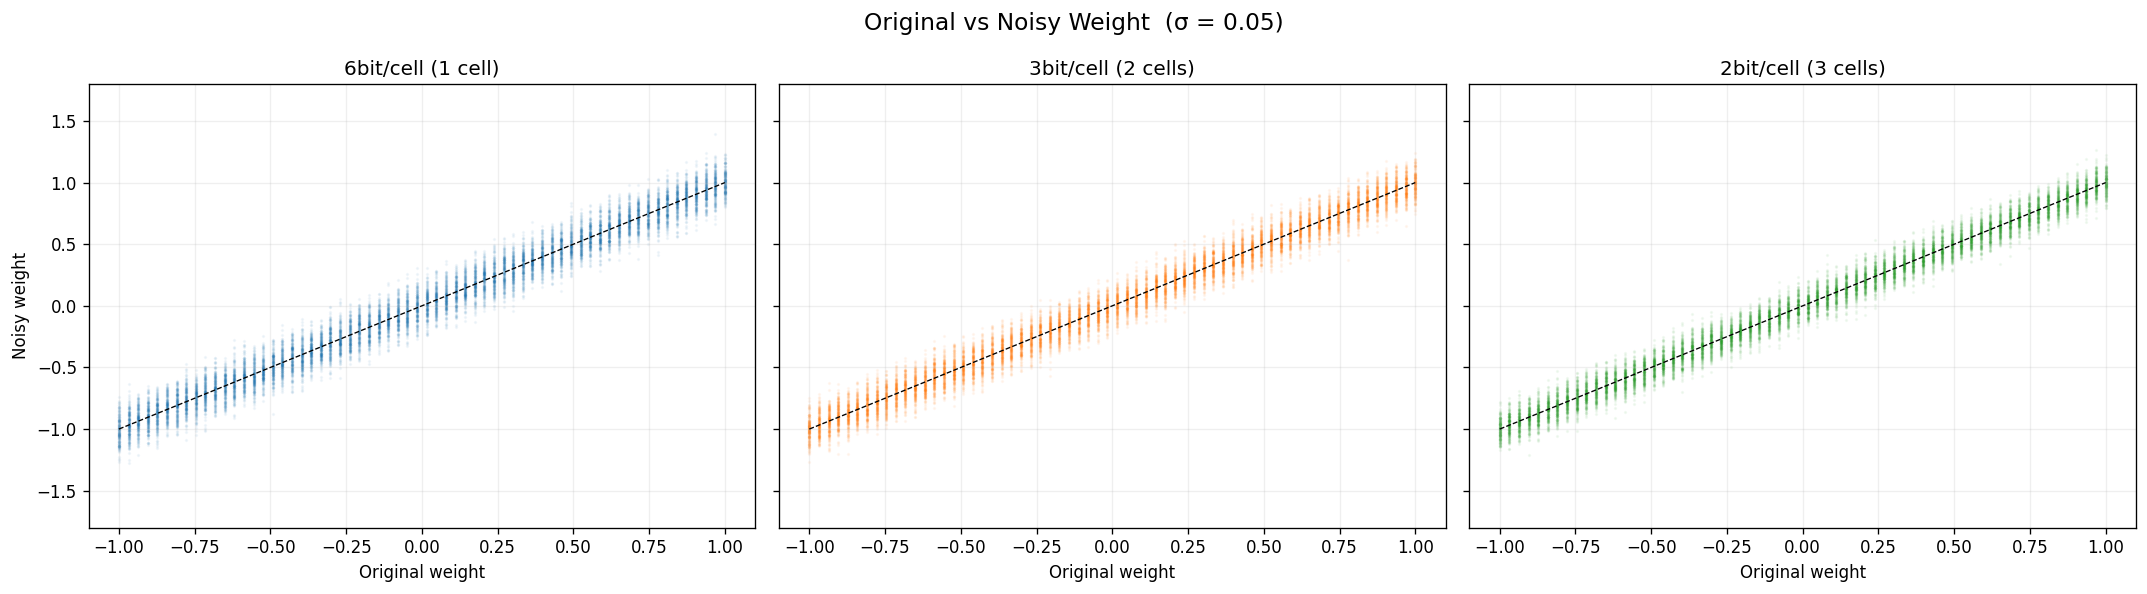

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, cfg in zip(axes, configs):
    w_orig, w_noisy, _ = inject_noise_mlc(
        q_values, sigma, bits, cfg['cell_bits'], n_trials=200
    )
    # 複数試行を重ね描き
    for t in range(w_noisy.shape[0]):
        ax.scatter(w_orig.numpy(), w_noisy[t].numpy(), s=1, alpha=0.05, color=cfg['color'])
    ax.plot([-1, 1], [-1, 1], 'k--', linewidth=0.8, label='ideal')
    ax.set_xlabel('Original weight')
    ax.set_title(f"{cfg['label']}")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.8, 1.8)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Noisy weight')
fig.suptitle(f'Original vs Noisy Weight  (σ = {sigma})', fontsize=14)
plt.tight_layout()
plt.show()

## 2. 重み誤差分布 (Error Distribution)
全量子化レベルを合算した誤差 $\Delta w = w_{\text{noisy}} - w_{\text{orig}}$ のヒストグラム。

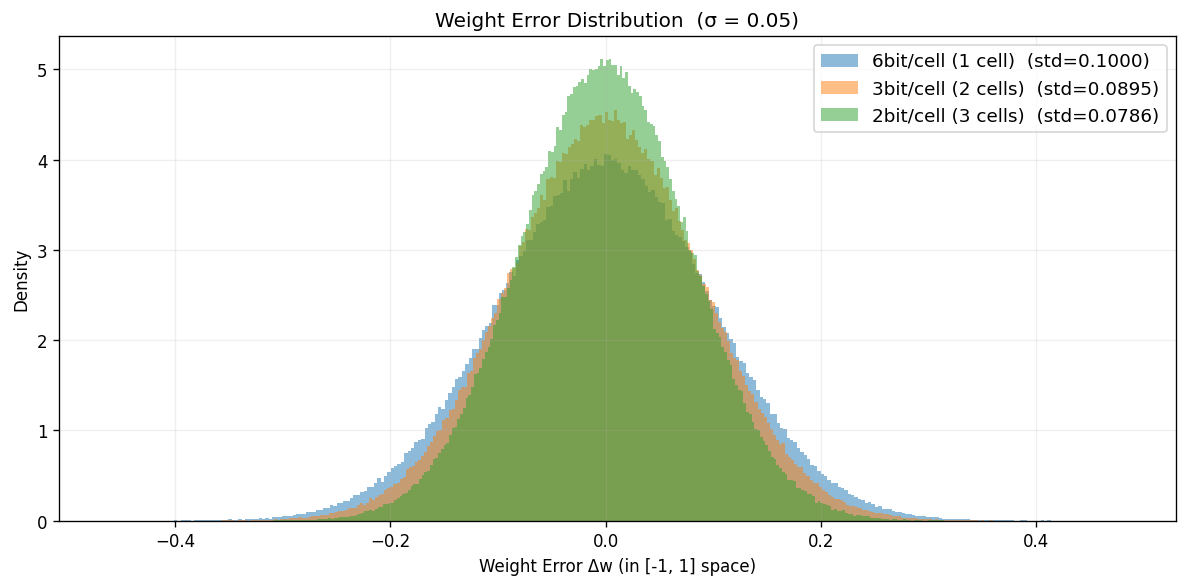

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

for cfg in configs:
    w_orig, w_noisy, _ = inject_noise_mlc(
        q_values, sigma, bits, cfg['cell_bits'], n_trials
    )
    errors = (w_noisy - w_orig.unsqueeze(0)).flatten().numpy()
    ax.hist(errors, bins=300, alpha=0.5, density=True, color=cfg['color'],
            label=f"{cfg['label']}  (std={errors.std():.4f})")

ax.set_xlabel('Weight Error Δw (in [-1, 1] space)')
ax.set_ylabel('Density')
ax.set_title(f'Weight Error Distribution  (σ = {sigma})')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 3. セルごとの誤差寄与 (Per-Cell Error Contribution)
各セルが出力重みの誤差にどの程度寄与するかを可視化。MSB セルほど寄与が大きい。

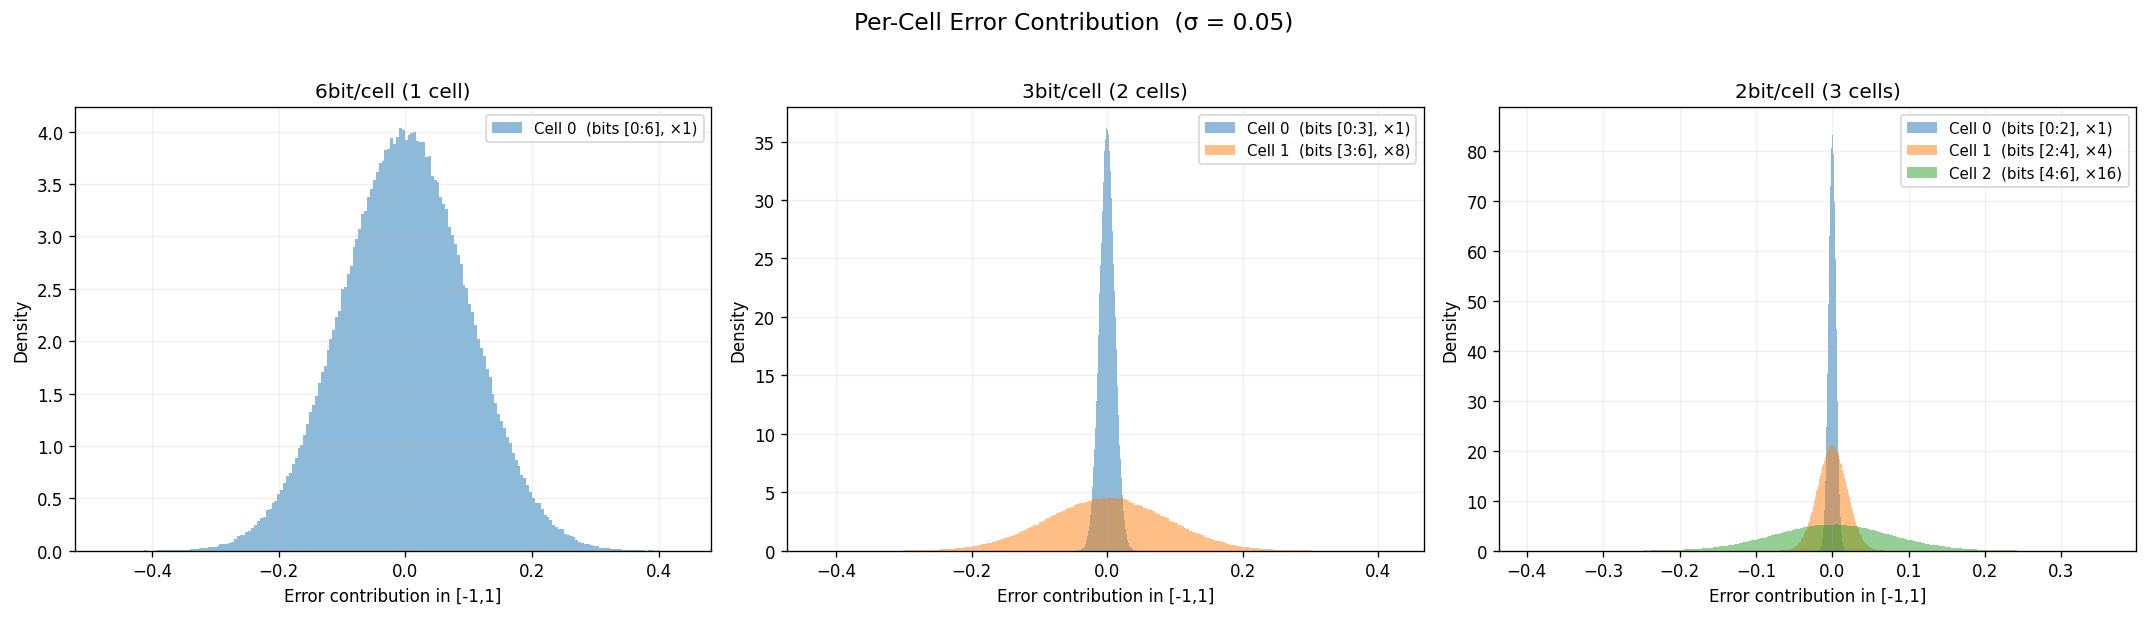

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cfg in zip(axes, configs):
    _, _, cell_errors = inject_noise_mlc(
        q_values, sigma, bits, cfg['cell_bits'], n_trials
    )
    num_cells = bits // cfg['cell_bits']
    for i, ce in enumerate(cell_errors):
        shift = i * cfg['cell_bits']
        bit_sig = 1 << shift
        ax.hist(ce.flatten().numpy(), bins=200, alpha=0.5, density=True,
                label=f'Cell {i}  (bits [{shift}:{shift+cfg["cell_bits"]}], ×{bit_sig})')
    ax.set_xlabel('Error contribution in [-1,1]')
    ax.set_ylabel('Density')
    ax.set_title(f'{cfg["label"]}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

fig.suptitle(f'Per-Cell Error Contribution  (σ = {sigma})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. 量子化レベルごとのノイズ標準偏差
各量子化値 $q \in [0, 63]$ でのノイズ標準偏差を比較。ノイズモデルがレベル非依存であることを確認する。

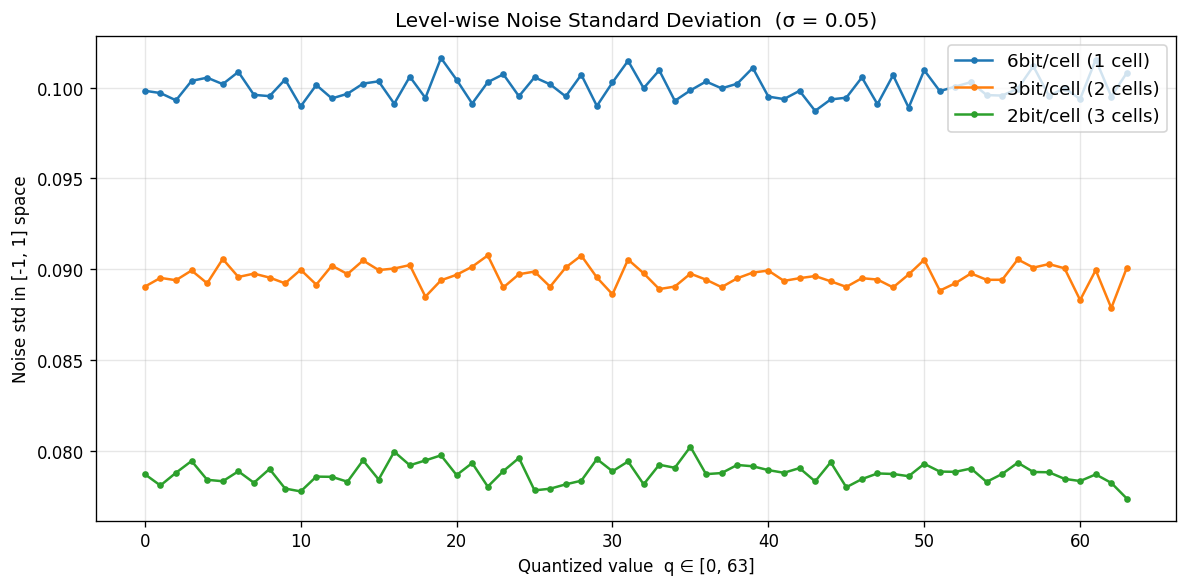

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

for cfg in configs:
    w_orig, w_noisy, _ = inject_noise_mlc(
        q_values, sigma, bits, cfg['cell_bits'], n_trials
    )
    noise_std = w_noisy.std(dim=0).numpy()  # 各レベルでの試行間 std
    ax.plot(q_values.numpy(), noise_std, 'o-', markersize=3,
            label=cfg['label'], color=cfg['color'])

ax.set_xlabel('Quantized value  q ∈ [0, 63]')
ax.set_ylabel('Noise std in [-1, 1] space')
ax.set_title(f'Level-wise Noise Standard Deviation  (σ = {sigma})')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. σ スイープ: 出力ノイズ vs 正規化シグマ
$\sigma$ を変化させた時の出力ノイズ Std を実測値と理論値で比較する。

**理論値**: $\text{Std}_{\text{total}} = \sigma \sqrt{\sum_{i} \left(\frac{2 \cdot \text{cell\_max} \cdot 2^{i \cdot \text{cell\_bits}}}{q_{\max}}\right)^2}$

/tmp/ipykernel_975713/713886803.py:35: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_975713/713886803.py:35: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_975713/713886803.py:35: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_975713/713886803.py:35: UserWarning: Glyph 35542 (\N{CJK UNIFIED IDEOGRAPH-8AD6}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3

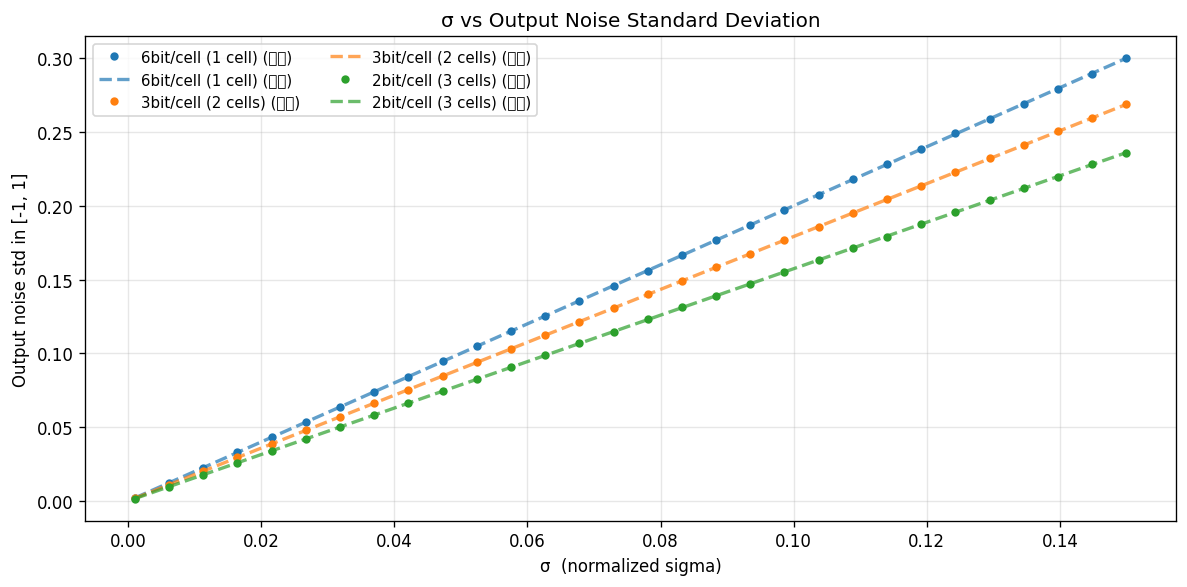


--- 理論的ノイズ増幅率 (σ=1 あたりの出力ノイズ std) ---
  6bit/cell (1 cell): 2.0000
  3bit/cell (2 cells): 1.7916
  2bit/cell (3 cells): 1.5736


In [10]:
sigmas = np.linspace(0.001, 0.15, 30)

fig, ax = plt.subplots(figsize=(10, 5))

for cfg in configs:
    cell_bits = cfg['cell_bits']
    cell_max = (1 << cell_bits) - 1
    num_cells = bits // cell_bits

    # 実測値
    rmses = []
    for s in sigmas:
        w_orig, w_noisy, _ = inject_noise_mlc(
            q_values, s, bits, cell_bits, n_trials=5000
        )
        err = (w_noisy - w_orig.unsqueeze(0)).flatten()
        rmses.append(err.std().item())
    ax.plot(sigmas, rmses, 'o', markersize=4, color=cfg['color'],
            label=f"{cfg['label']} (実測)")

    # 理論値
    total_var_factor = sum(
        (cell_max * (1 << (i * cell_bits)) * 2.0 / qmax) ** 2
        for i in range(num_cells)
    )
    theoretical = sigmas * np.sqrt(total_var_factor)
    ax.plot(sigmas, theoretical, '--', linewidth=2, alpha=0.7, color=cfg['color'],
            label=f"{cfg['label']} (理論)")

ax.set_xlabel('σ  (normalized sigma)')
ax.set_ylabel('Output noise std in [-1, 1]')
ax.set_title('σ vs Output Noise Standard Deviation')
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 理論的ノイズ増幅率を表示
print("\n--- 理論的ノイズ増幅率 (σ=1 あたりの出力ノイズ std) ---")
for cfg in configs:
    cell_bits = cfg['cell_bits']
    cell_max = (1 << cell_bits) - 1
    num_cells = bits // cell_bits
    factor = np.sqrt(sum(
        (cell_max * (1 << (i * cell_bits)) * 2.0 / qmax) ** 2
        for i in range(num_cells)
    ))
    print(f"  {cfg['label']}: {factor:.4f}")